# Downstream Analysis

This notebook should be used for downstream analysis of your OPS screen.
Cells marked with <font color='red'>SET PARAMETERS</font> contain crucial variables that need to be set according to your specific experimental setup and data organization.
Please review and modify these variables as needed before proceeding with the analysis.

## <font color='red'>SET PARAMETERS</font>

### Fixed parameters for cluster module

- `CONFIG_FILE_PATH`: Path to a Brieflow config file used during processing. Absolute or relative to where workflows are run from.

In [1]:
CONFIG_FILE_PATH = "config/config.yml"

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
import yaml
import pandas as pd
import matplotlib as plt

from lib.cluster.cluster_analysis import (
    differential_analysis, 
    waterfall_plot, 
    two_feature_plot, 
    cluster_heatmap
)
from lib.cluster.phate_leiden_clustering import plot_phate_leiden_clusters
from lib.shared.metrics import get_all_stats

In [3]:
# load config file and determine root path
with open(CONFIG_FILE_PATH, "r") as config_file:
    config = yaml.safe_load(config_file)
    ROOT_FP = Path(config["all"]["root_fp"])

## Pipeline Statistics Report

This function analyzes the entire data processing pipeline from raw microscopy images to clustered perturbation profiles. It will:

1. **Preprocessing**: Count input files and generated image tiles
2. **SBS**: Analyze cell segmentation and barcode mapping success rates
3. **Phenotype**: Count cells and morphological features extracted
4. **Merge**: Calculate how many cells were successfully matched between SBS and phenotype data
5. **Aggregation**: Measure perturbation coverage and batch effect correction (per cell class/channel)
6. **Clustering**: Evaluate pathway enrichment and optimal clustering parameters

**Expected runtime: 5-15 minutes** depending on dataset size, as this function loads and analyzes large parquet files to calculate batch statistics and enrichment metrics.

The report will display progress updates as each stage is analyzed.

In [4]:
# statistics = get_all_stats(config)

In [5]:
# Load cell classes and channel combos
cluster_combo_fp = config["cluster"]["cluster_combo_fp"]
cluster_combos = pd.read_csv(cluster_combo_fp, sep="\t")

CHANNEL_COMBOS = list(cluster_combos["channel_combo"].unique())
print(f"Channel Combos: {CHANNEL_COMBOS}")

CELL_CLASSES = list(cluster_combos["cell_class"].unique())
print(f"Cell classes: {CELL_CLASSES}")

LEIDEN_RESOLUTION = list(cluster_combos["leiden_resolution"].unique())
print(f"Leiden resolution: {LEIDEN_RESOLUTION}")

Channel Combos: ['DAPI_Ki-67_COXIV_Caspase-3_WGA_aTubulin_Vimentin_gH2AX_Phalloidin', 'DAPI_aTubulin_gH2AX_Phalloidin']
Cell classes: ['Interphase', 'Mitotic', 'all']
Leiden resolution: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]


## <font color='red'>SET PARAMETERS</font>

### Cluster Selection for Analysis

Set these parameters to select the specific cluster data to analyze:
- `CHANNEL_COMBO`: Select from available channel combinations,
- `CELL_CLASS`: Select from available cell classes,
- `LEIDEN_RESOLUTION`: Select from available Leiden resolutions,

These parameters determine which folder of cluster data will be analyzed.

In [6]:
CHANNEL_COMBO = "DAPI_Ki-67_COXIV_Caspase-3_WGA_aTubulin_Vimentin_gH2AX_Phalloidin"
CELL_CLASS = "all"
LEIDEN_RESOLUTION = 5

In [7]:
aggregate_file = ROOT_FP / "aggregate" / "tsvs" / f"CeCl-{CELL_CLASS}_ChCo-{CHANNEL_COMBO}__feature_table.tsv"
print(f"Aggregate file: {aggregate_file}")

if not aggregate_file.exists():
    print(f"Aggregate file does not exist: {aggregate_file}")
else:
    print(f"Aggregate file found")

cluster_path = ROOT_FP / "cluster" / CHANNEL_COMBO / CELL_CLASS / str(LEIDEN_RESOLUTION)
print(f"Cluster path: {cluster_path}")

if not cluster_path.exists():
    print(f"Cluster directory does not exist: {cluster_path}")
else:
    print(f"Cluster directory found")

Aggregate file: brieflow_output/aggregate/tsvs/CeCl-all_ChCo-DAPI_Ki-67_COXIV_Caspase-3_WGA_aTubulin_Vimentin_gH2AX_Phalloidin__feature_table.tsv
Aggregate file found
Cluster path: brieflow_output/cluster/DAPI_Ki-67_COXIV_Caspase-3_WGA_aTubulin_Vimentin_gH2AX_Phalloidin/all/5
Cluster directory found


## Feature Plot Analysis

This section generates visualizations to explore the phenotypic effects of gene perturbations in your screen. The plots will help you:

1. **Differential Feature Analysis**: Identify genes with significant phenotypic changes vs. controls
2. **Waterfall Plots**: Rank genes by their effect on specific features of interest
3. **Two-Feature Plots**: Discover relationships between different phenotypic measurements
4. **Heatmaps**: Visualize patterns across multiple features and gene sets simultaneously

The interactive analysis allow you to customize each visualization for your specific biological questions.

In [8]:
cluster_file = cluster_path / "phate_leiden_clustering.tsv"
cluster_df = pd.read_csv(cluster_file, sep="\t")
display(cluster_df)

,gene_symbol_0,cell_count,PHATE_0,PHATE_1,cluster,uniprot_entry,uniprot_function,uniprot_link,mean_potential_to_nontargeting,normalized_potential_to_nontargeting
0,nontargeting_noncutting_CAAACATGTTGG,239,0.025067,0.007082,0,NaN,NaN,NaN,10.852847,0.082373
1,F11_KLKB1,6082,0.022578,0.005632,0,NaN,NaN,NaN,8.708954,0.052925
2,nontargeting_noncutting_CCGCGTATCGAT,254,0.021815,0.005294,0,NaN,NaN,NaN,8.504774,0.050120
3,nontargeting_noncutting_CAGAAATGCGCA,286,0.023668,0.005913,0,NaN,NaN,NaN,9.565436,0.064689
4,nontargeting_noncutting_TAGCGACGCAAA,287,0.021122,0.005965,0,NaN,NaN,NaN,8.111528,0.044719
...,...,...,...,...,...,...,...,...,...,...
1436,nontargeting_intergenic_CCTTCTCACAAT,1156,0.014839,0.002490,76,NaN,NaN,NaN,5.026431,0.002343
1437,ARFGEF2,2124,0.009557,0.000820,77,Q9Y6D5,Promotes guanine-nucleotide exchange on ARF1 a...,https://www.uniprot.org/uniprotkb/Q9Y6D5/entry,6.080796,0.016825
1438,SUPT20H,1830,0.002979,0.002729,77,Q8NEM7,"Required for MAP kinase p38 (MAPK11, MAPK12, M...",https://www.uniprot.org/uniprotkb/Q8NEM7/entry,9.315399,0.061255
1439,SLC20A2,3541,0.015485,0.003005,77,Q08357,Sodium-phosphate symporter which preferentiall...,https://www.uniprot.org/uniprotkb/Q08357/entry,5.247908,0.005385


In [9]:
aggregate_df = pd.read_csv(aggregate_file, sep="\t")
display(aggregate_df)

,gene_symbol_0,nucleus_DAPI_int,nucleus_Ki-67_int,nucleus_COXIV_int,nucleus_Caspase-3_int,nucleus_WGA_int,nucleus_aTubulin_int,nucleus_Vimentin_int,nucleus_gH2AX_int,nucleus_Phalloidin_int,...,cell_manders_aTubulin_WGA,cell_manders_Vimentin_WGA,cell_manders_gH2AX_WGA,cell_manders_Phalloidin_WGA,cell_manders_Vimentin_aTubulin,cell_manders_gH2AX_aTubulin,cell_manders_Phalloidin_aTubulin,cell_manders_gH2AX_Vimentin,cell_manders_Phalloidin_Vimentin,cell_manders_Phalloidin_gH2AX
0,CKS2_CKS1B,-0.453572,-0.258693,-0.112196,-0.155257,-0.132608,-0.286114,-0.113097,-0.116004,-0.121747,...,0.078580,0.177299,0.104496,0.095395,0.327846,0.167962,0.184153,-0.024958,-0.041407,0.001167
1,BTRC_FBXW11,-0.518174,-0.305467,-0.118774,-0.241929,-0.218318,-0.294194,-0.029245,-0.240707,-0.337639,...,-0.014760,0.188649,-0.029953,-0.001269,0.267048,-0.005029,0.077628,-0.310186,-0.273912,-0.099942
2,TOMM40L_TOMM40,-0.486881,-0.189455,-0.136168,-0.069559,-0.096763,-0.186091,0.065822,0.046108,-0.120823,...,-0.076254,0.068032,-0.047731,-0.063673,0.229047,0.090452,0.112749,-0.035871,-0.022703,-0.134254
3,KBTBD7_KBTBD6,-0.519542,-0.137716,-0.290599,-0.133929,-0.190500,-0.209679,-0.065911,-0.071407,-0.214481,...,-0.032647,0.094933,-0.022315,-0.050539,0.218214,0.054386,0.065365,-0.061698,-0.066347,-0.132729
4,CRY2,-0.515082,-0.197797,-0.188654,-0.134718,-0.114583,-0.191481,-0.182124,-0.134347,-0.075109,...,0.086121,0.186070,0.102154,0.095699,0.209152,0.041265,0.081447,0.004852,-0.007679,0.007457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,nontargeting_intergenic_TACTTACAGAGC_TACTTACAGAGC,-0.518716,-0.197239,-0.033578,-0.148605,-0.176931,-0.265409,-0.135016,-0.259847,-0.209277,...,0.224746,0.303759,0.216424,0.129858,0.294223,0.169264,0.114236,0.093022,0.042194,0.095600
1437,OR2M7,-0.529670,-0.202915,-0.296386,-0.166336,-0.163725,-0.230560,-0.200458,-0.062721,-0.224478,...,-0.010836,0.087602,0.029935,0.008197,0.127303,-0.016387,-0.034512,-0.036640,-0.048672,-0.010784
1438,OR2A25,-0.536932,-0.218964,-0.122062,-0.126943,-0.222907,-0.165739,-0.114735,-0.109648,-0.175592,...,-0.003716,0.110470,0.001699,0.022285,0.272276,0.114482,0.112115,-0.136005,-0.102868,-0.056137
1439,nontargeting_noncutting_CGTACGCTTCTG,-0.615515,-0.055797,0.024850,-0.311665,-0.350208,-0.190433,-0.132166,-0.267614,-0.061340,...,0.509976,0.421098,0.558670,0.444468,0.281650,0.398016,0.340642,0.047941,0.240400,0.131405


OR_CONTROL targets found: {'OR5AR1', 'OR4D1', 'OR5W2', 'OR10H4', 'OR2A25', 'OR10A5', 'OR5B3', 'OR56B1', 'OR13G1', 'OR5K2', 'OR4C5', 'OR1D5', 'OR2T11', 'OR6C2', 'OR1E1', 'OR4F29', 'OR4F4', 'OR11H1', 'OR13C2', 'OR52K1', 'OR9Q2', 'OR10X1', 'OR5T3', 'OR13D1', 'OR2V2', 'OR8B3', 'OR1J1', 'OR2M7', 'OR5C1', 'OR6T1', 'OR10A6', 'OR13C3', 'OR4Q3', 'OR6X1', 'OR2L3', 'OR8G5', 'OR5M3', 'OR1S2', 'OR51B2', 'OR51T1', 'OR1F1', 'OR4D6', 'OR10A2', 'OR4E2', 'OR4K15', 'OR4K2', 'OR10W1', 'OR51E1', 'OR10T2', 'OR1Q1', 'OR10Q1', 'OR8B8', 'OR4F5', 'OR52B2', 'OR2A14', 'OR4N4', 'OR4C13', 'OR10P1', 'OR52N1', 'OR52I1', 'OR4D2', 'OR5K1', 'OR3A1', 'OR10D3', 'OR10H5', 'OR52E2', 'OR2T8', 'OR52E8', 'OR6K2', 'OR2D2', 'OR2G2', 'OR4B1', 'OR2A42', 'OR2T4', 'OR2T6', 'OR51A2', 'OR51M1', 'OR1L1', 'OR1A1', 'OR2D3', 'OR5H1', 'OR10G4', 'OR6M1', 'OR2C3', 'OR14J1', 'OR8K3', 'OR8D4', 'OR1K1', 'OR2T10', 'OR1L6', 'OR5J2', 'OR4F21', 'OR4P4', 'OR4F3', 'OR2B6', 'OR56A5', 'OR52E6', 'OR4A5', 'OR8U3', 'OR11A1'}
Creating Plot 1: Controls Grou

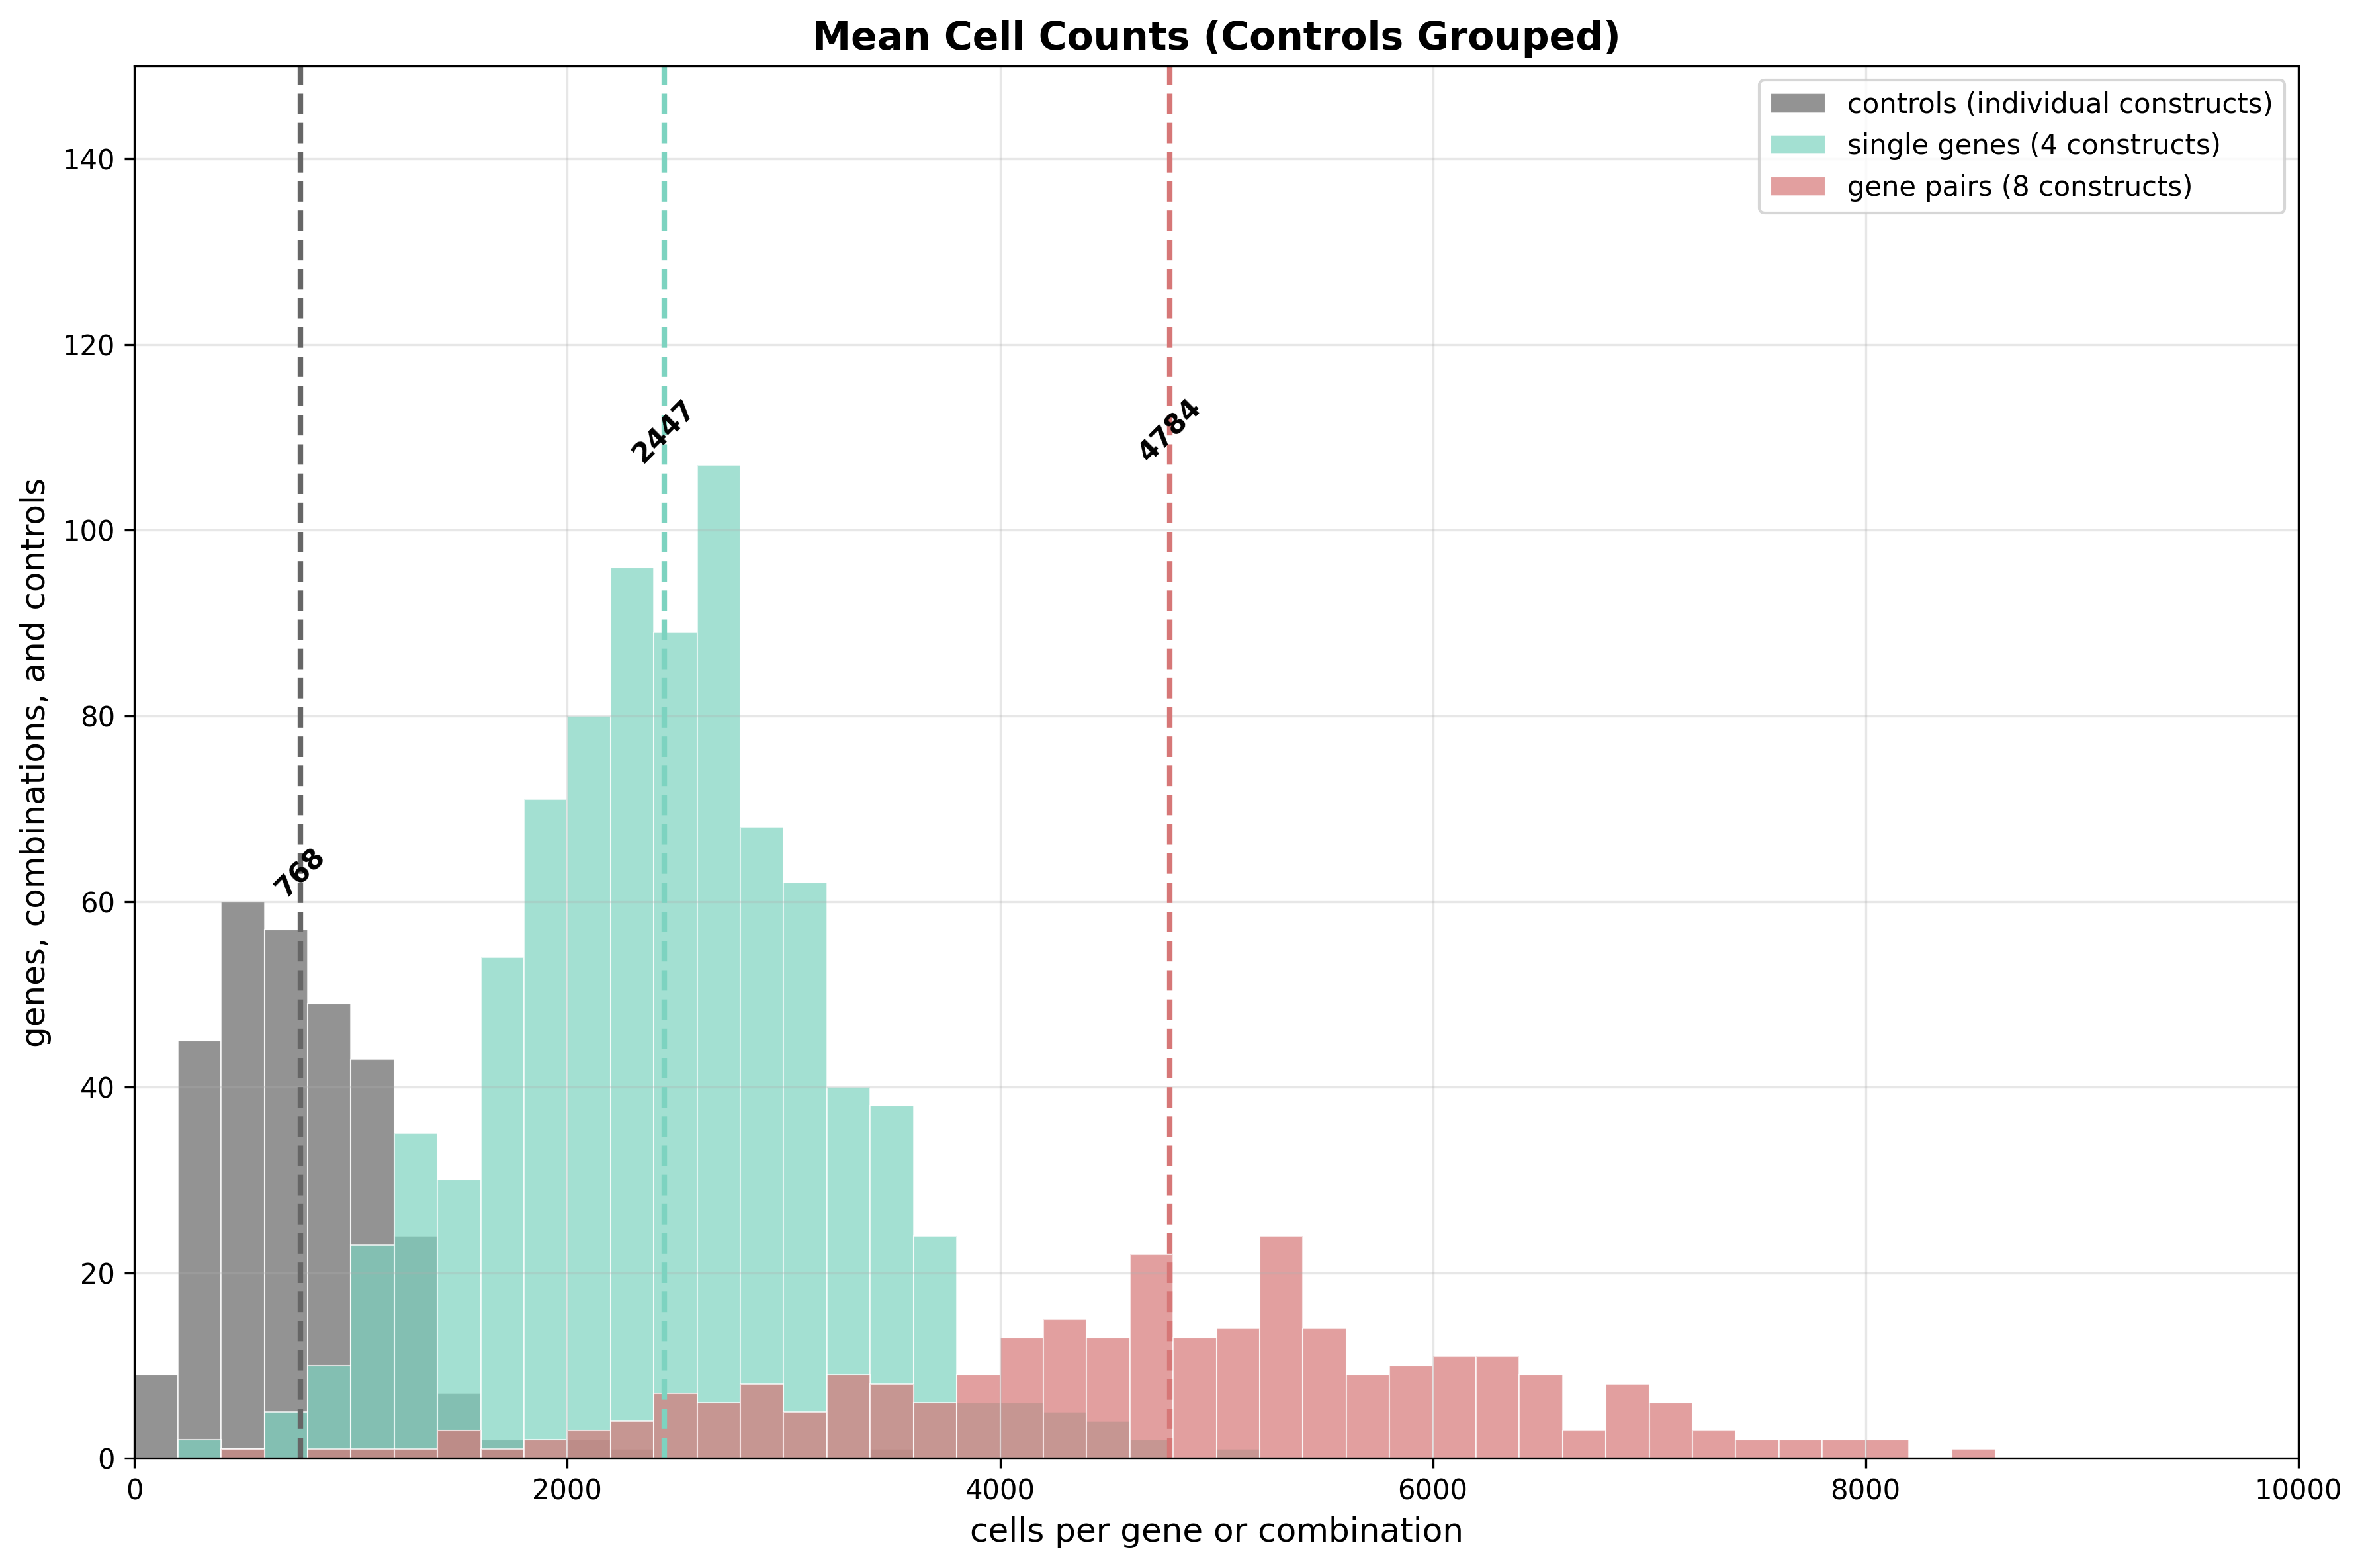


Creating Plot 2: Controls Separated


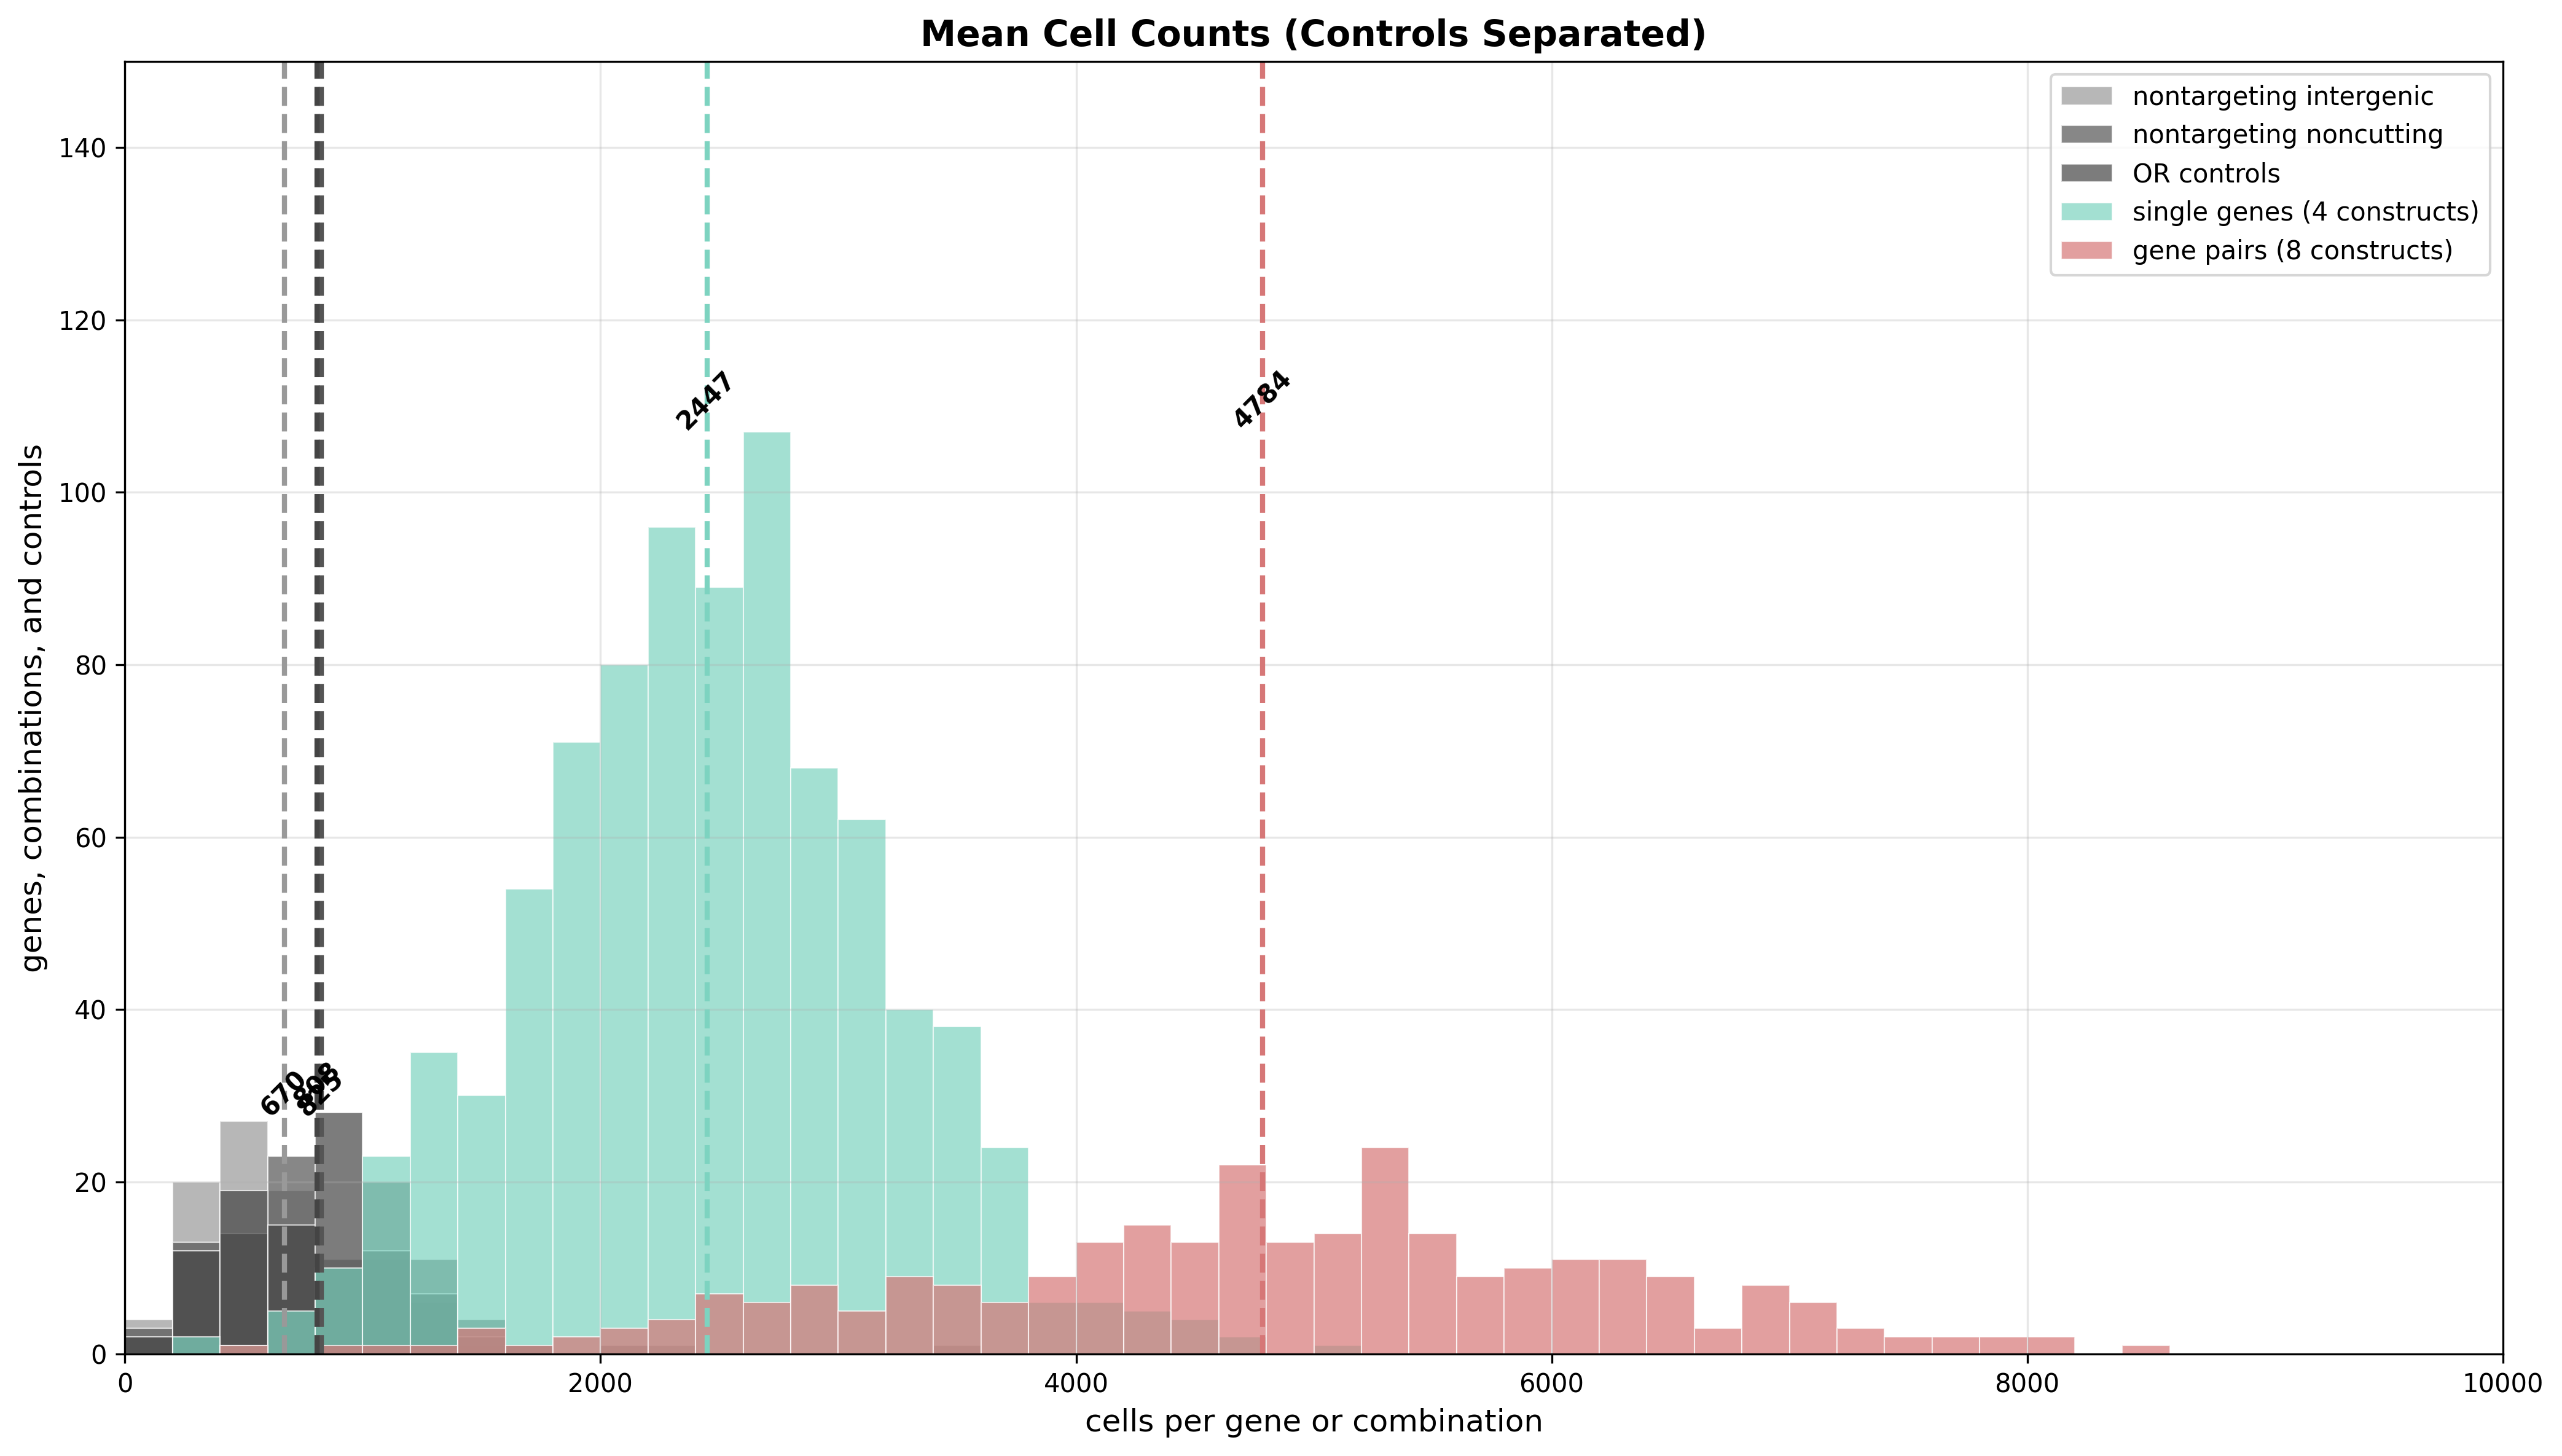


Summary Statistics - Controls Grouped:

controls (individual constructs):
  Count: 300
  Mean: 767.7
  Median: 714.5
  Min: 7
  Max: 3545

single genes (4 constructs):
  Count: 859
  Mean: 2447.3
  Median: 2443.0
  Min: 301
  Max: 5073

gene pairs (8 constructs):
  Count: 282
  Mean: 4784.0
  Median: 4837.0
  Min: 576
  Max: 8477

Construct Type Distribution:
construct_type_grouped
single genes (4 constructs)         859
controls (individual constructs)    300
gene pairs (8 constructs)           282
Name: count, dtype: int64

Summary Statistics - Controls Separated:

nontargeting intergenic:
  Count: 100
  Mean: 669.9
  Median: 584.5
  Min: 155
  Max: 2034

nontargeting noncutting:
  Count: 100
  Mean: 825.2
  Median: 789.5
  Min: 7
  Max: 2267

OR controls:
  Count: 100
  Mean: 808.0
  Median: 806.5
  Min: 138
  Max: 3545

single genes (4 constructs):
  Count: 859
  Mean: 2447.3
  Median: 2443.0
  Min: 301
  Max: 5073

gene pairs (8 constructs):
  Count: 282
  Mean: 4784.0
  Median: 

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

library_design_df = pd.read_csv("config/HeLa_combo_library_design.20240624-115737.csv")

# First, get the OR_CONTROL targets from library_design_df
or_control_targets = set(library_design_df[library_design_df['category'] == 'OR_CONTROL']['target'].unique())
print(f"OR_CONTROL targets found: {or_control_targets}")

# Create categorization function for grouped controls
def categorize_construct_grouped(gene_symbol):
    if pd.isna(gene_symbol):
        return 'controls (individual constructs)'
    elif (gene_symbol.startswith('nontargeting') or 
          gene_symbol in or_control_targets):
        return 'controls (individual constructs)'
    elif '_' in gene_symbol:
        return 'gene pairs (8 constructs)'
    else:
        return 'single genes (4 constructs)'

# Create categorization function for separated controls
def categorize_construct_separated(gene_symbol):
    if pd.isna(gene_symbol):
        return 'other controls'
    elif gene_symbol.startswith('nontargeting_intergenic'):
        return 'nontargeting intergenic'
    elif gene_symbol.startswith('nontargeting_noncutting'):
        return 'nontargeting noncutting'
    elif gene_symbol.startswith('nontargeting'):
        return 'other nontargeting'
    elif gene_symbol in or_control_targets:
        return 'OR controls'
    elif '_' in gene_symbol:
        return 'gene pairs (8 constructs)'
    else:
        return 'single genes (4 constructs)'

# Apply both categorizations
cluster_df['construct_type_grouped'] = cluster_df['gene_symbol_0'].apply(categorize_construct_grouped)
cluster_df['construct_type_separated'] = cluster_df['gene_symbol_0'].apply(categorize_construct_separated)

# Set up the plotting parameters
plt.rcParams['figure.dpi'] = 300
bins = np.arange(0, 11000, 200)

# Define colors for grouped plot
colors_grouped = {
    'controls (individual constructs)': '#666666',
    'single genes (4 constructs)': '#7dd3c0',
    'gene pairs (8 constructs)': '#d67777'
}

# Define colors for separated plot
colors_separated = {
    'nontargeting intergenic': '#999999',
    'nontargeting noncutting': '#555555', 
    'OR controls': '#444444',
    'other controls': '#333333',
    'other nontargeting': '#777777',
    'single genes (4 constructs)': '#7dd3c0',
    'gene pairs (8 constructs)': '#d67777'
}

def create_histogram(df, construct_col, colors, title, figsize=(12, 8)):
    """Helper function to create histogram plots"""
    fig, ax = plt.subplots(figsize=figsize)
    
    # Get existing construct types in order
    if construct_col == 'construct_type_grouped':
        plot_order = ['controls (individual constructs)', 'single genes (4 constructs)', 'gene pairs (8 constructs)']
    else:
        plot_order = [
            'nontargeting intergenic', 
            'nontargeting noncutting', 
            'OR controls',
            'other controls',
            'other nontargeting',
            'single genes (4 constructs)', 
            'gene pairs (8 constructs)'
        ]
    
    existing_types = df[construct_col].unique()
    plot_order = [ct for ct in plot_order if ct in existing_types]
    
    for construct_type in plot_order:
        data = df[df[construct_col] == construct_type]['cell_count']
        
        # Plot histogram
        ax.hist(data, bins=bins, alpha=0.7, color=colors[construct_type], 
                label=construct_type, edgecolor='white', linewidth=0.5)
        
        # Calculate and plot mean line
        mean_val = data.mean()
        ax.axvline(mean_val, color=colors[construct_type], linestyle='--', linewidth=2)
        
        # Add mean value text above the line
        ax.text(mean_val, ax.get_ylim()[1] * 0.95, f'{mean_val:.0f}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold',
                rotation=45)
    
    # Customize the plot
    ax.set_xlabel('cells per gene or combination', fontsize=12)
    ax.set_ylabel('genes, combinations, and controls', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 10000)
    ax.set_ylim(0, 150)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return plot_order

def print_summary_stats(df, construct_col, plot_order, title):
    """Helper function to print summary statistics"""
    print(f"\n{title}")
    print("=" * 60)
    for construct_type in plot_order:
        data = df[df[construct_col] == construct_type]['cell_count']
        print(f"\n{construct_type}:")
        print(f"  Count: {len(data)}")
        print(f"  Mean: {data.mean():.1f}")
        print(f"  Median: {data.median():.1f}")
        print(f"  Min: {data.min()}")
        print(f"  Max: {data.max()}")
    
    print(f"\nConstruct Type Distribution:")
    print("=" * 40)
    print(df[construct_col].value_counts())

# Create Plot 1: Grouped controls
print("Creating Plot 1: Controls Grouped Together")
plot_order_grouped = create_histogram(
    cluster_df, 
    'construct_type_grouped', 
    colors_grouped, 
    'Mean Cell Counts (Controls Grouped)',
    figsize=(12, 8)
)

# Create Plot 2: Separated controls
print("\nCreating Plot 2: Controls Separated")
plot_order_separated = create_histogram(
    cluster_df, 
    'construct_type_separated', 
    colors_separated, 
    'Mean Cell Counts (Controls Separated)',
    figsize=(14, 8)
)

# Print summary statistics for both
print_summary_stats(cluster_df, 'construct_type_grouped', plot_order_grouped, 
                   "Summary Statistics - Controls Grouped:")

print_summary_stats(cluster_df, 'construct_type_separated', plot_order_separated, 
                   "Summary Statistics - Controls Separated:")

In [9]:
for index, gene_symbol in enumerate(cluster_df['gene_symbol_0']):
    print(f"{index}: {gene_symbol}")

0: nontargeting_noncutting_CAAACATGTTGG
1: F11_KLKB1
2: nontargeting_noncutting_CCGCGTATCGAT
3: nontargeting_noncutting_CAGAAATGCGCA
4: nontargeting_noncutting_TAGCGACGCAAA
5: nontargeting_noncutting_CGGTCCGACACA
6: nontargeting_noncutting_CGGACTAACGTT
7: nontargeting_noncutting_TGCTGGCCATCA
8: nontargeting_noncutting_TCAGGGTGGCAT
9: nontargeting_noncutting_CATCCGTCCAAG
10: nontargeting_noncutting_TGGAGCACCACA
11: nontargeting_noncutting_CGTAATTAGCAT
12: nontargeting_noncutting_TAACACTGTCTC
13: OR8D4
14: OR14J1
15: OR10A6
16: nontargeting_noncutting_CAACTGTCATTC
17: nontargeting_noncutting_CTTCTTCTTCCT
18: nontargeting_noncutting_CTGATACCGCTG
19: nontargeting_noncutting_TCTACATTGCAC
20: nontargeting_noncutting_TGCTGAATAATC
21: nontargeting_noncutting_CAGTGCGGGTCA
22: nontargeting_noncutting_TATATCCGCTTG
23: nontargeting_noncutting_CGCAAGTGGACC
24: nontargeting_noncutting_TATCGTTTGAGT
25: nontargeting_noncutting_CCATTCCTAGTA
26: nontargeting_noncutting_CCACCTACAACG
27: nontargeting_nonc

## <font color='red'>SET PARAMETERS</font>

### Cluster Selection for Visualization

Set these parameters to select the specific cluster to analyze:
- `CLUSTER_ID`: The cluster of interest to generate plots.

In [10]:
CLUSTER_ID = None

In [11]:
print(f"\n{'='*50}")
print(f"Analyzing Cluster {CLUSTER_ID}")
cluster_genes = cluster_df[cluster_df['cluster'] == CLUSTER_ID][config["aggregate"]["perturbation_name_col"]]
print(f"Genes in Cluster {CLUSTER_ID}:" ,", ".join(cluster_genes.unique()))
print(f"{'='*50}")

# Run differential analysis using robust z-score
diff_results = differential_analysis(
    feature_df=aggregate_df,  
    cluster_df=cluster_df,    
    cluster_id=CLUSTER_ID,
    control_type="nontargeting",  
    control_label=config["aggregate"]["control_key"],
    use_nonparametric=True,  
    normalize_method="robust_zscore"
)

# Display results in a more user-friendly format
print("\nTop Upregulated Features:")
up_df = diff_results['top_up'][['feature', 'robust_zscore', 'p_value', 'median_test', 'median_control']]
up_df = up_df.rename(columns={
    'robust_zscore': 'Z-score',
    'p_value': 'p-value',
    'median_test': 'Median (test)',
    'median_control': 'Median (control)'
})
display(up_df.style.format({
    'Z-score': '{:.2f}',
    'p-value': '{:.2e}',
    'Median (test)': '{:.3f}',
    'Median (control)': '{:.3f}'
}))

print("\nTop Downregulated Features:")
down_df = diff_results['top_down'][['feature', 'robust_zscore', 'p_value', 'median_test', 'median_control']]
down_df = down_df.rename(columns={
    'robust_zscore': 'Z-score',
    'p_value': 'p-value',
    'median_test': 'Median (test)',
    'median_control': 'Median (control)'
})
display(down_df.style.format({
    'Z-score': '{:.2f}',
    'p-value': '{:.2e}',
    'Median (test)': '{:.3f}',
    'Median (control)': '{:.3f}'
}))


Analyzing Cluster None
Genes in Cluster None: 

Top Upregulated Features:


KeyError: "None of [Index(['feature', 'robust_zscore', 'p_value', 'median_test', 'median_control'], dtype='object')] are in the [columns]"

## <font color='red'>SET PARAMETERS</font>

### Feature Selection for Visualization

Set these parameters to select the specific cluster to analyze:
- `FEATURES_TO_ANALYZE`: The features found in the differential analysis to generate plots for.
- `GENES_TO_LABEL`: The genes within the cluster to label on the plots.

In [ ]:
FEATURES_TO_ANALYZE = None
GENES_TO_LABEL = None

In [ ]:
# Create waterfall plots for selected features
print("\n--- Waterfall Plots for Selected Features ---")
for feature in FEATURES_TO_ANALYZE:
    print(f"\nPlotting: {feature}")
    waterfall_plot(
        feature_df=aggregate_df, 
        feature=feature,
        cluster_df=cluster_df,
        cluster_id=CLUSTER_ID,
        nontargeting_pattern=config["aggregate"]["control_key"],
        title=f"Cluster {CLUSTER_ID}: {feature}",
        label_genes=GENES_TO_LABEL
    )

# Create two-feature plots for combinations
print("\n--- Two-Feature Plots ---")
# Generate all unique pairs of features
feature_pairs = [(FEATURES_TO_ANALYZE[i], FEATURES_TO_ANALYZE[j]) 
                 for i in range(len(FEATURES_TO_ANALYZE)) 
                 for j in range(i+1, len(FEATURES_TO_ANALYZE))]

for feature1, feature2 in feature_pairs:
    print(f"\nPlotting: {feature1} vs {feature2}")
    two_feature_plot(
        feature_df=aggregate_df,
        x=feature1,
        y=feature2,
        cluster_df=cluster_df,
        cluster_id=CLUSTER_ID,
        nontargeting_pattern=config["aggregate"]["control_key"],
        title=f"Cluster {CLUSTER_ID}: {feature1} vs {feature2}",
        label_genes=GENES_TO_LABEL
    )

# Create heatmap with all differential features
print("\n--- Heatmap of Differential Features ---")
# Get top features from differential analysis
top_up = diff_results['top_up']['feature'].tolist() if not diff_results['top_up'].empty else []
top_down = diff_results['top_down']['feature'].tolist() if not diff_results['top_down'].empty else []
diff_features = top_up + top_down

fig, ax, heatmap_data = cluster_heatmap(
    feature_df=aggregate_df,
    cluster_df=cluster_df,
    cluster_ids=[CLUSTER_ID],
    features=diff_features,
    perturbation_name_col=config["aggregate"]["perturbation_name_col"],
    z_score="global",
    title=f"Cluster {CLUSTER_ID}: Top Differential Features",
)

# PHATE plot for the cluster
print("\n--- PHATE Plot for Cluster ---")
phate_fig = plot_phate_leiden_clusters(
    phate_leiden_clustering=cluster_df,
    perturbation_name_col=config["aggregate"]["perturbation_name_col"],
    control_key=config["aggregate"]["control_key"],
    clusters_of_interest=[CLUSTER_ID],
)

## Mozzarellm: LLM-based Gene Cluster Analysis

### Overview
[Mozzarellm](https://github.com/cheeseman-lab/mozzarellm) is a Python package that leverages Large Language Models (LLMs) to analyze gene clusters for pathway identification and novel gene discovery. This notebook guides you through the process of:

1. **Loading and reshaping gene cluster data** from your OPS screen
2. **Analyzing gene clusters with LLMs** to identify biological pathways
3. **Categorizing genes** as established pathway members, uncharacterized, or having novel potential roles
4. **Prioritizing candidates** for experimental validation

### Prerequisites

You need to install the mozzarellm package in your Brieflow environment:

```bash
pip install git+https://github.com/cheeseman-lab/mozzarellm.git
```

Mozzarellm requires API keys to access LLM services. You need at least one of these keys:

- **OpenAI API Key**: Required for GPT models (gpt-4o, gpt-4.5, etc.)
- **Anthropic API Key**: Required for Claude models (claude-3-7-sonnet, etc.)
- **Google API Key**: Required for Gemini models (gemini-2.0-pro, etc.)

These keys provide access to paid API services, and usage will incur costs based on the number of tokens processed. The cost per analysis varies by model but typically ranges from $0.01-$0.10 per cluster, depending on cluster size and model choice. For this reason, we only run these analyses on a specific chosen Leiden resolution, rather than across all of the generated possible resolutions.

In [ ]:
from mozzarellm import analyze_gene_clusters, reshape_to_clusters

In [ ]:
# Set API keys
os.environ["OPENAI_API_KEY"] = "your_openai_key_here"
os.environ["ANTHROPIC_API_KEY"] = "your_anthropic_key_here"  
os.environ["GOOGLE_API_KEY"] = "your_google_key_here"

In [ ]:
RESULTS_DIR = cluster_path / "mozzarellm_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

In [ ]:
cluster_file = cluster_path / "phate_leiden_clustering.tsv"
cluster_df = pd.read_csv(cluster_file, sep="\t")
display(cluster_df)

## <font color='red'>SET PARAMETERS</font>: 

### Data Reshaping

Configure gene clustering parameters:
- `GENE_COL`: Column containing gene identifiers
- `CLUSTER_COL`: Column containing cluster assignments
- `UNIPROT_COL`: Column with UniProt annotations

These parameters control how gene-level data is converted to cluster-level data. These are set to default values that will be established in upstream notebooks/snakemakes, and usually don't need to be manipulated.

In [ ]:
GENE_COL = config["aggregate"]["perturbation_name_col"]
CLUSTER_COL = "cluster"
UNIPROT_COL = "uniprot_function"

In [ ]:
llm_cluster_df, llm_uniprot_df = reshape_to_clusters(
    input_df=cluster_df, 
    gene_col=GENE_COL,
    cluster_col=CLUSTER_COL,
    uniprot_col=UNIPROT_COL, 
    verbose=True
)
display(llm_cluster_df)
display(llm_uniprot_df)

## <font color='red'>SET PARAMETERS</font>: 
### LLM Analysis Configuration

- `MODEL_NAME`: LLM to use for analysis. Usable models include:
  - OpenAI: `o4-mini`, `o3-mini`, `gpt-4.1`, `gpt-4o`
  - Anthropic: `claude-3-7-sonnet-20250219`, `claude-3-5-haiku-20241022`
  - Google: `gemini-2.5-pro-preview-03-25`, `gemini-2.5-flash-preview-04-17`
- `CONFIG_DICT`: Configuration file for the LLM model
- `SCREEN_CONTEXT`: Context for the analysis and how to evaluate _clusters_
- `CLUSTER_ANALYSIS_PROMPT`: Context for the analysis and how to evaluate _genes within clusters_

Mozzarellm includes optimized [configurations](https://github.com/cheeseman-lab/mozzarellm/blob/main/mozzarellm/configs.py) and [prompts](https://github.com/cheeseman-lab/mozzarellm/blob/main/mozzarellm/prompts.py) you can import as shown below.

Custom text files can also be used by setting `screen_context_path` and `cluster_analysis_prompt_path` parameters.

In [ ]:
from mozzarellm.prompts import ROBUST_SCREEN_CONTEXT, ROBUST_CLUSTER_PROMPT
from mozzarellm.configs import DEFAULT_ANTHROPIC_CONFIG

In [ ]:
# Set up model configs
MODEL_NAME = "claude-3-7-sonnet-20250219"
CONFIG_DICT = DEFAULT_ANTHROPIC_CONFIG
SCREEN_CONTEXT = ROBUST_SCREEN_CONTEXT
CLUSTER_ANALYSIS_PROMPT = ROBUST_CLUSTER_PROMPT

In [ ]:
# Run LLM analysis
anthropic_results = analyze_gene_clusters(
    # Input data options
    input_df=llm_cluster_df,
    # Model and configuration
    model_name=MODEL_NAME,
    config_dict=CONFIG_DICT,
    # Analysis context and prompts
    screen_context=SCREEN_CONTEXT,
    cluster_analysis_prompt=CLUSTER_ANALYSIS_PROMPT,
    # Gene annotations
    gene_annotations_df=llm_uniprot_df,
    # Processing options
    batch_size=1,
    # Output options
    output_file=f"{RESULTS_DIR}/{MODEL_NAME}",
    save_outputs=True,
    outputs_to_generate=["json", "clusters", "flagged_genes"],
)